In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
!pip install kneed
from kneed import KneeLocator
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster

In [ ]:
df_ori = pd.read_csv ('https://raw.githubusercontent.com/Livanty/DatasetW2/refs/heads/main/ecommerce_sales_analysis.csv')
df_ori.head()

,product_id,product_name,category,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12
0,1,Product_1,Clothing,190.40,1.7,220,479,449,92,784,604,904,446,603,807,252,695,306
1,2,Product_2,Home & Kitchen,475.60,3.2,903,21,989,861,863,524,128,610,436,176,294,772,353
2,3,Product_3,Toys,367.34,4.5,163,348,558,567,143,771,409,290,828,340,667,267,392
3,4,Product_4,Toys,301.34,3.9,951,725,678,59,15,937,421,670,933,56,157,168,203
4,5,Product_5,Books,82.23,4.2,220,682,451,649,301,620,293,411,258,854,548,770,257


### **Data Cleaning**

In [ ]:
df_ori.isnull().sum()

,0
product_id,0
product_name,0
category,0
price,0
review_score,0
review_count,0
sales_month_1,0
sales_month_2,0
sales_month_3,0
sales_month_4,0


In [ ]:
df_ori.drop(['product_name'], axis=1, inplace=True)
df_ori.head()

,product_id,category,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12
0,1,Clothing,190.40,1.7,220,479,449,92,784,604,904,446,603,807,252,695,306
1,2,Home & Kitchen,475.60,3.2,903,21,989,861,863,524,128,610,436,176,294,772,353
2,3,Toys,367.34,4.5,163,348,558,567,143,771,409,290,828,340,667,267,392
3,4,Toys,301.34,3.9,951,725,678,59,15,937,421,670,933,56,157,168,203
4,5,Books,82.23,4.2,220,682,451,649,301,620,293,411,258,854,548,770,257


In [ ]:
# Menghitung rata-rata penjualan per bulan
df_ori['avg_sales'] = df_ori[['sales_month_1', 'sales_month_2', 'sales_month_3',
                      'sales_month_4', 'sales_month_5', 'sales_month_6',
                      'sales_month_7', 'sales_month_8', 'sales_month_9',
                      'sales_month_10', 'sales_month_11', 'sales_month_12']].mean(axis=1)

In [ ]:
df_ori.duplicated().value_counts()

,count
False,1000


### **Data Preparation - Transformation**

In [ ]:

label_encoder = LabelEncoder()
df = df_ori.copy()
df['category'] = label_encoder.fit_transform(df['category'])
df.head()


,product_id,category,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12,avg_sales
0,1,1,190.40,1.7,220,479,449,92,784,604,904,446,603,807,252,695,306,535.083333
1,2,4,475.60,3.2,903,21,989,861,863,524,128,610,436,176,294,772,353,502.250000
2,3,6,367.34,4.5,163,348,558,567,143,771,409,290,828,340,667,267,392,465.000000
3,4,6,301.34,3.9,951,725,678,59,15,937,421,670,933,56,157,168,203,418.500000
4,5,0,82.23,4.2,220,682,451,649,301,620,293,411,258,854,548,770,257,507.833333


In [ ]:
df.drop([ 'sales_month_1', 'sales_month_2', 'sales_month_3',
    'sales_month_4', 'sales_month_5', 'sales_month_6',
    'sales_month_7', 'sales_month_8', 'sales_month_9',
    'sales_month_10', 'sales_month_11', 'sales_month_12'], axis=1, inplace=True)
df.head()

,product_id,category,price,review_score,review_count,avg_sales
0,1,1,190.40,1.7,220,535.083333
1,2,4,475.60,3.2,903,502.250000
2,3,6,367.34,4.5,163,465.000000
3,4,6,301.34,3.9,951,418.500000
4,5,0,82.23,4.2,220,507.833333


In [ ]:
sc = MinMaxScaler()
df= pd.DataFrame(sc.fit_transform(df), columns=['product_id', 'category', 'price', 'review_score', 'review_count', 'avg_sales'])
df.head()

,product_id,category,price,review_score,review_count,avg_sales
0,0.000000,0.166667,0.371744,0.175,0.219439,0.558181
1,0.001001,0.666667,0.950748,0.550,0.903808,0.494417
2,0.002002,1.000000,0.730962,0.875,0.162325,0.422075
3,0.003003,1.000000,0.596971,0.725,0.951904,0.331769
4,0.004004,0.000000,0.152141,0.800,0.219439,0.505260


# **EDA**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    1000 non-null   float64
 1   category      1000 non-null   float64
 2   price         1000 non-null   float64
 3   review_score  1000 non-null   float64
 4   review_count  1000 non-null   float64
 5   avg_sales     1000 non-null   float64
dtypes: float64(6)
memory usage: 47.0 KB


In [ ]:
df.describe()

,product_id,category,price,review_score,review_count,avg_sales
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.500000,0.500667,0.488026,0.506900,0.526559,0.493269
std,0.289109,0.340921,0.293579,0.292811,0.282836,0.160588
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.250000,0.166667,0.232495,0.250000,0.283317,0.391649
50%,0.500000,0.500000,0.494610,0.525000,0.543086,0.488752
75%,0.750000,0.833333,0.743336,0.750000,0.772545,0.600097
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


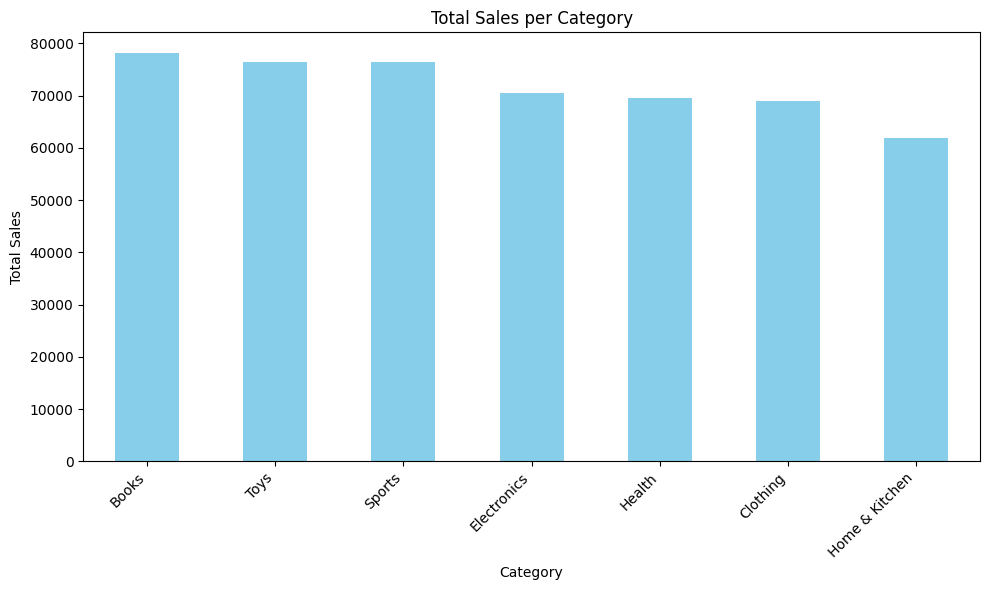

In [ ]:
import matplotlib.pyplot as plt


# Group by category and sum the total sales for each category
category_sales = df_ori.groupby('category')['avg_sales'].sum().sort_values(ascending=False)

# Plot the bar chart
plt.figure(figsize=(10,6))
category_sales.plot(kind='bar', color='skyblue')
plt.title('Total Sales per Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


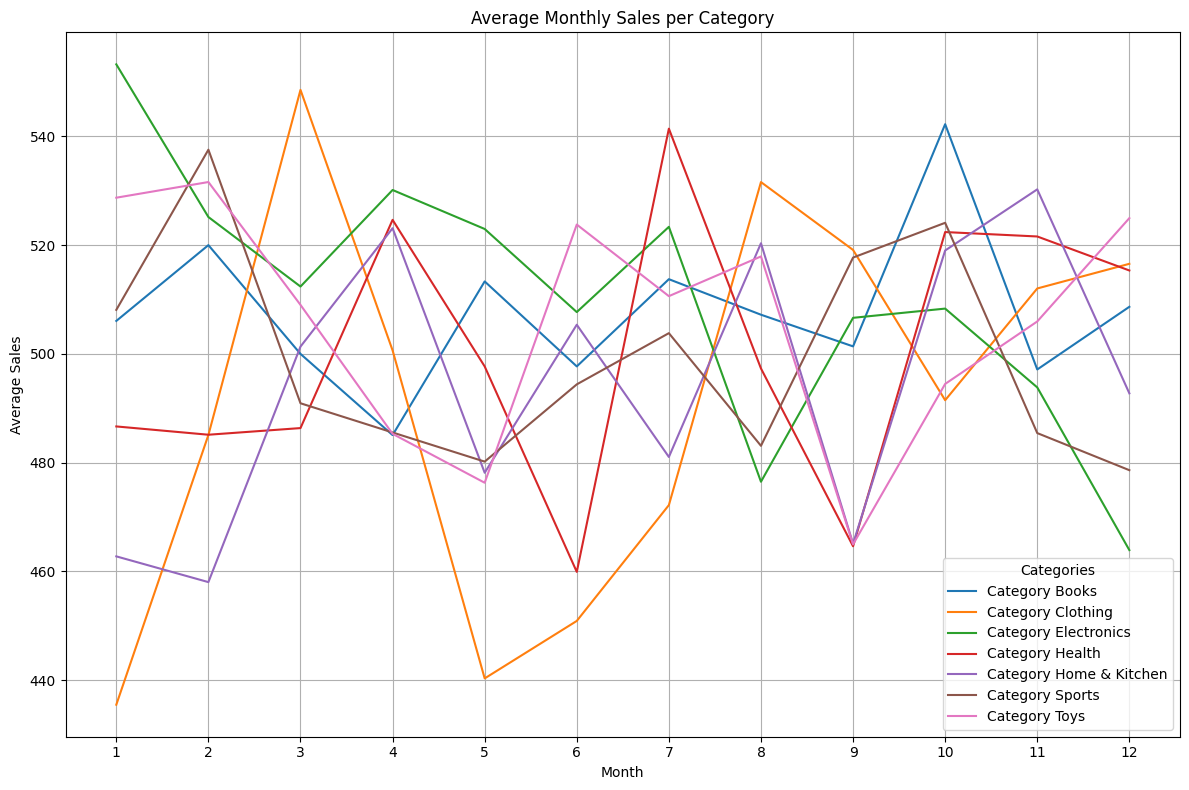

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_inverse contains your original data with 'avg_sales' and 'category' columns

# Melt the DataFrame to long format
df_melted = df_ori.melt(
    id_vars=['product_id', 'category'],
    value_vars=[f'sales_month_{i}' for i in range(1, 13)],  # Only sales month columns
    var_name='Month',
    value_name='Sales'
)

# Convert 'Month' to integer
df_melted['Month'] = df_melted['Month'].str.replace('sales_month_', '').astype(int)

# Group by category and month to calculate average sales
avg_sales_by_category = df_melted.groupby(['category', 'Month'])['Sales'].mean().reset_index()

# Plot
plt.figure(figsize=(12, 8))
for category in avg_sales_by_category['category'].unique():
    category_data = avg_sales_by_category[avg_sales_by_category['category'] == category]
    plt.plot(category_data['Month'], category_data['Sales'], label=f'Category {category}')

plt.title('Average Monthly Sales per Category')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(range(1, 13))
plt.legend(title='Categories')
plt.grid(True)
plt.tight_layout()
plt.show()

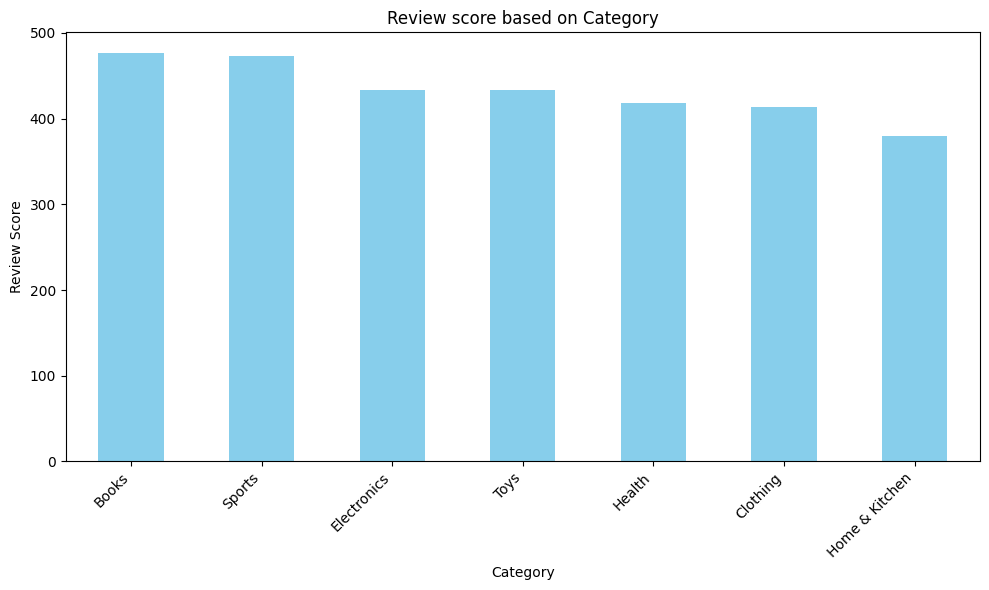

In [ ]:
import matplotlib.pyplot as plt


# Group by category and sum the total sales for each category
category_sales = df_ori.groupby('category')['review_score'].sum().sort_values(ascending=False)

# Plot the bar chart
plt.figure(figsize=(10,6))
category_sales.plot(kind='bar', color='skyblue')
plt.title('Review score based on Category')
plt.xlabel('Category')
plt.ylabel('Review Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **K-Means Clustering**

In [ ]:
# set the parameter for evaluating K

# set the parameter for evaluating K
sse = []
# check the inertia for each K
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='random', max_iter=300, random_state=42)
    kmeans.fit(df)
    sse.append(kmeans.inertia_)

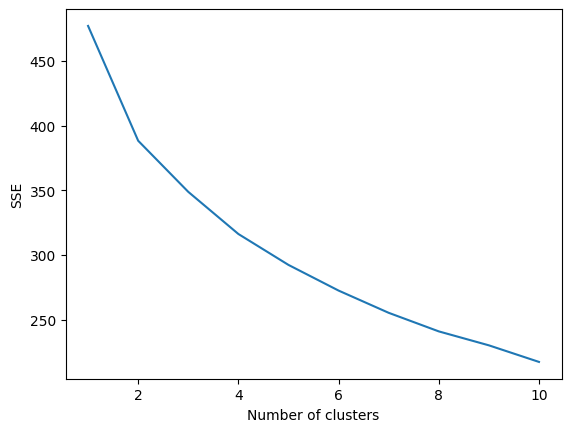

In [ ]:
# manually visualize the elbow method using plotlib
plt.plot(range(1, 11), sse)
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.show()

In [ ]:

# using kneelocator to find the elbow/knee
kneedle = KneeLocator(range(1, 11), sse, curve="convex", direction="decreasing")
print("The best k for your model is", kneedle.elbow)

The best k for your model is 4


In [ ]:

kmeans = KMeans(n_clusters=4, init='random', max_iter=300, random_state=42)
y_pred = kmeans.fit_predict(df)
y_pred

array([2, 1, 1, 1, 0, 3, 0, 1, 2, 0, 3, 1, 0, 2, 0, 0, 3, 1, 0, 3, 0, 2,
       0, 1, 0, 2, 0, 1, 2, 0, 2, 0, 2, 1, 2, 1, 3, 3, 1, 3, 3, 0, 3, 1,
       0, 1, 3, 3, 0, 2, 1, 0, 1, 1, 0, 2, 0, 3, 0, 0, 0, 0, 1, 0, 3, 0,
       3, 2, 0, 2, 1, 3, 3, 2, 1, 1, 1, 3, 2, 0, 1, 2, 0, 3, 0, 3, 1, 2,
       1, 2, 0, 0, 0, 0, 2, 2, 2, 3, 0, 2, 3, 0, 0, 1, 1, 2, 0, 0, 3, 2,
       0, 2, 2, 1, 1, 0, 2, 3, 2, 3, 1, 1, 0, 3, 3, 3, 1, 2, 2, 2, 0, 0,
       3, 3, 0, 3, 0, 2, 0, 1, 0, 3, 0, 0, 2, 3, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 2, 0, 0, 2, 1, 3, 1, 0, 2, 0, 0, 3, 2, 2, 0, 0, 1, 3, 1, 0,
       1, 2, 1, 3, 0, 0, 1, 1, 2, 0, 0, 2, 3, 3, 3, 1, 1, 1, 2, 0, 1, 1,
       1, 1, 0, 3, 3, 2, 1, 0, 3, 1, 2, 3, 2, 1, 1, 3, 1, 2, 2, 0, 0, 2,
       1, 3, 3, 0, 3, 3, 1, 3, 0, 2, 1, 3, 2, 2, 3, 1, 3, 0, 0, 3, 1, 0,
       1, 0, 3, 1, 2, 2, 0, 1, 0, 0, 2, 3, 3, 1, 1, 1, 2, 3, 2, 1, 3, 3,
       1, 2, 1, 2, 3, 2, 0, 0, 0, 2, 0, 2, 2, 0, 1, 1, 1, 0, 3, 2, 2, 0,
       3, 3, 2, 3, 3, 3, 1, 0, 0, 3, 2, 2, 1, 3, 3,

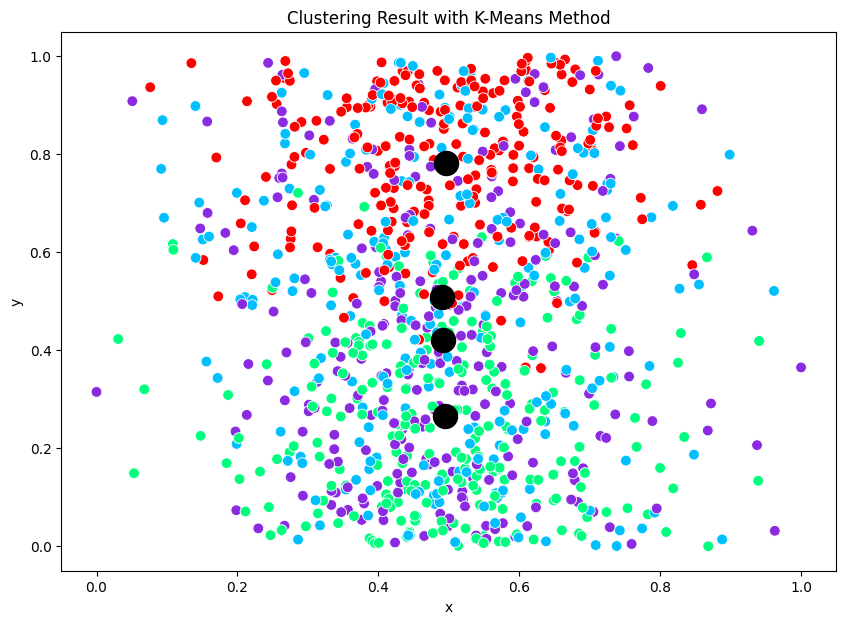

In [ ]:
# visualize the result using scater chart
plt.figure(figsize=(10,7))


sns.scatterplot(x="avg_sales", y="price", hue=y_pred, palette=[
    "blueviolet",
    "red",
    "deepskyblue",
    "springgreen"
], legend=None, data=df, s=60)

plt.scatter(kmeans.cluster_centers_[:, 5], kmeans.cluster_centers_[:, 2], s=300, c="black")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Clustering Result with K-Means Method")
plt.show()

In [ ]:
df.head()

,product_id,category,price,review_score,review_count,avg_sales
0,0.000000,0.166667,0.371744,0.175,0.219439,0.558181
1,0.001001,0.666667,0.950748,0.550,0.903808,0.494417
2,0.002002,1.000000,0.730962,0.875,0.162325,0.422075
3,0.003003,1.000000,0.596971,0.725,0.951904,0.331769
4,0.004004,0.000000,0.152141,0.800,0.219439,0.505260


In [ ]:
# Inverse transform the scaled data to get the original values
df_inverse = pd.DataFrame(sc.inverse_transform(df), columns=['product_id', 'category', 'price', 'review_score', 'review_count',
    'avg_sales'])
# Add the cluster labels to the original data
df_inverse['Cluster'] = y_pred
# Analyze the clusters with the original values
df_inverse.head()

,product_id,category,price,review_score,review_count,avg_sales,Cluster
0,1.0,1.0,190.40,1.7,220.0,535.083333,2
1,2.0,4.0,475.60,3.2,903.0,502.250000,1
2,3.0,6.0,367.34,4.5,163.0,465.000000,1
3,4.0,6.0,301.34,3.9,951.0,418.500000,1
4,5.0,0.0,82.23,4.2,220.0,507.833333,0


In [ ]:
# Group the data by cluster and calculate the mean spending and annual income for each cluster
cluster_summary = df_inverse.groupby(y_pred).agg({
    'price': ['mean', 'std', 'min', 'max'],           # Harga produk
    'review_score': ['mean', 'std', 'min', 'max'],    # Skor ulasan
    'review_count': ['mean', 'std', 'min', 'max'],    # Jumlah ulasan
    'category': [pd.Series.mode],                    # Kategori dominan

    'avg_sales': ['mean', 'std', 'min', 'max']       # Penjualan rata-rata
})
cluster_summary = cluster_summary.T

# Ubah nama klaster menjadi 'Cluster 0', 'Cluster 1', dll.
cluster_summary.columns = [f'Cluster {i}' for i in range(cluster_summary.shape[1])]

# Menambahkan nama 'KMeans' pada level pertama kolom
cluster_summary.columns.name = 'KMeans'

# Menampilkan hasil
cluster_summary

KMeans              Cluster 0   Cluster 1   Cluster 2   Cluster 3
price        mean  214.294508  392.165127  258.312561  137.824882
             std   132.500092   71.586737  141.176595   86.014329
             min     9.550000  186.350000    7.510000    7.290000
             max   499.860000  498.340000  498.450000  362.520000
review_score mean    4.038636    3.431356    1.910976    2.683071
             std     0.630124    0.996863    0.611723    1.080911
             min     2.400000    1.000000    1.000000    1.000000
             max     5.000000    5.000000    3.600000    5.000000
review_count mean  476.363636  553.436441  543.207317  537.425197
             std   273.661645  294.952835  278.746834  277.522738
             min     8.000000    1.000000   13.000000    1.000000
             max   996.000000  998.000000  998.000000  999.000000
category     mode    0.000000    5.000000    1.000000    6.000000
avg_sales    mean  501.045770  502.850989  500.494919  502.317585
             std    84.894067   76.306487   87.963087   81.254363
             min   247.666667  286.916667  294.916667  263.500000
             max   762.583333  701.500000  742.833333  731.916667

In [ ]:
df_inverse['Cluster'].value_counts().sort_index()

,count
Cluster,
0,264
1,236
2,246
3,254


# **Hierarchical Clustering**

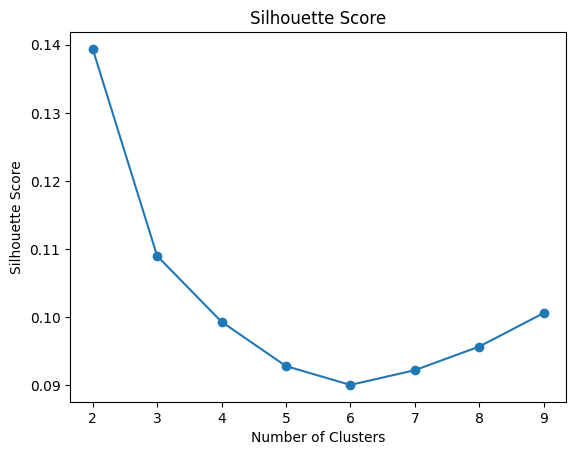

In [ ]:
silhouette_scores = []

# The range was changed to start from 2, ensuring at least 2 clusters are formed.
for i in range(2, 10):
    cluster_labels = fcluster(linkage(df, method='ward'), i, criterion='maxclust')
    silhouette_avg = silhouette_score(df, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot Silhouette Score = the higher the better
plt.plot(range(2, 10), silhouette_scores, marker='o') # Adjusted x-axis range to match the loop
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

In [ ]:
silhouette_scores = []
for k in range(2, 10):  # Mencoba jumlah cluster dari 2 hingga 9
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df)  # X adalah dataset
    score = silhouette_score(df, labels)
    silhouette_scores.append(score)
    print(f"Jumlah Cluster: {k}, Silhouette Score: {score}")

Jumlah Cluster: 2, Silhouette Score: 0.1751105382721434
Jumlah Cluster: 3, Silhouette Score: 0.14658124287379237
Jumlah Cluster: 4, Silhouette Score: 0.14383089315746395
Jumlah Cluster: 5, Silhouette Score: 0.1426802962359639
Jumlah Cluster: 6, Silhouette Score: 0.1475605876254694
Jumlah Cluster: 7, Silhouette Score: 0.14966865023120124
Jumlah Cluster: 8, Silhouette Score: 0.1590118742918754
Jumlah Cluster: 9, Silhouette Score: 0.14631621105992276


In [ ]:

# Add the cluster labels to the original data that you have been added with kmeans so you have a full dataframe include kmeans and agglo clustering
agglo = AgglomerativeClustering(n_clusters=3)
agglo_labels = agglo.fit_predict(df)

# Step 2: Add Agglomerative Clustering labels to the original DataFrame
df_inverse['agglo'] = agglo_labels

# show the df
df_inverse.head()

,product_id,category,price,review_score,review_count,avg_sales,Cluster,agglo
0,1.0,1.0,190.40,1.7,220.0,535.083333,2,0
1,2.0,4.0,475.60,3.2,903.0,502.250000,1,2
2,3.0,6.0,367.34,4.5,163.0,465.000000,1,2
3,4.0,6.0,301.34,3.9,951.0,418.500000,1,2
4,5.0,0.0,82.23,4.2,220.0,507.833333,0,0


In [ ]:
# Function to calculate mode for each cluster
def mode(series):
    return series.mode().iloc[0] if not series.mode().empty else np.nan

# Repeat for Agglomerative Clustering
agglo_summary = df_inverse.groupby(agglo_labels).agg({
     'price': ['mean', 'std', 'min', 'max'],           # Harga produk
    'review_score': ['mean', 'std', 'min', 'max'],    # Skor ulasan
    'review_count': ['mean', 'std', 'min', 'max'],    # Jumlah ulasan
    'category': [pd.Series.mode],                    # Kategori dominan
    'avg_sales': ['mean', 'std', 'min', 'max']       # Penjualan rata-rata
})
agglo_summary = agglo_summary.T
agglo_summary = agglo_summary.rename_axis(index={'agglo': agglo_summary.index.levels[0].name})
agglo_summary

0           1           2
price        mean  247.695807  196.712899  290.205474
             std   144.475445  133.102041  140.704583
             min     8.440000    7.290000   10.620000
             max   499.860000  495.030000  496.520000
review_score mean    3.098952    1.966807    3.794035
             std     1.165208    0.660928    0.802680
             min     1.000000    1.000000    1.200000
             max     5.000000    3.900000    5.000000
review_count mean  514.364780  493.264706  574.585965
             std   279.640618  286.420336  277.939901
             min     8.000000    1.000000    1.000000
             max   999.000000  982.000000  998.000000
category     mode    0.000000    6.000000    5.000000
avg_sales    mean  498.915968  503.290966  504.888304
             std    83.803905   80.925035   82.403267
             min   247.666667  263.500000  275.083333
             max   743.416667  742.833333  762.583333

In [ ]:
cluster_counts = df_inverse['agglo'].value_counts().sort_index()
cluster_counts

,count
agglo,
0,477
1,238
2,285


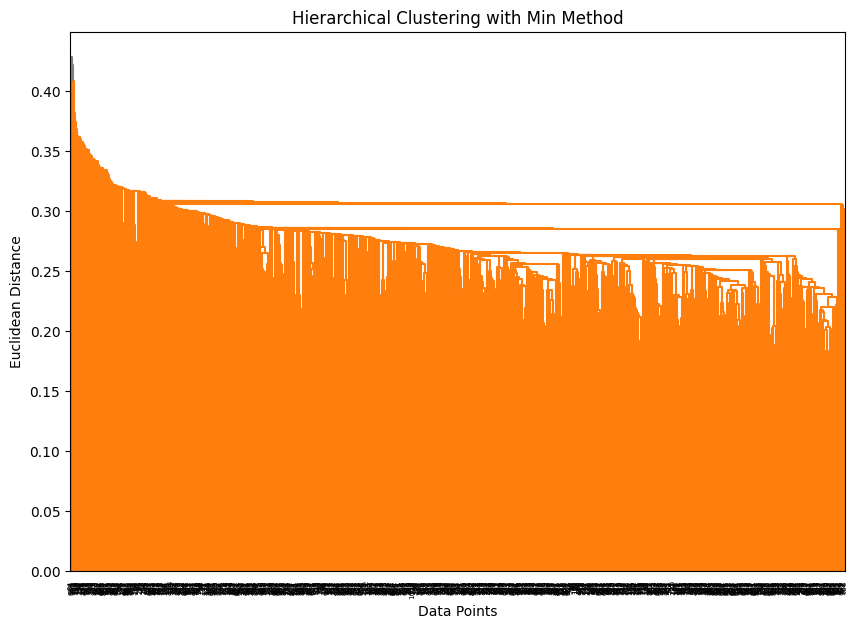

In [ ]:
import scipy.cluster.hierarchy as sch
# Min Distance
# Buat linkage matrix
linked = linkage(df, method='single')

# Tentukan jumlah cluster yang diinginkan
n_clusters = 3

# Gunakan fcluster untuk mendapatkan label cluster
cluster_labels = fcluster(linked, t=n_clusters, criterion='distance')

# Tentukan color_threshold agar sesuai dengan pemotongan
color_threshold = linked[-(n_clusters-1), 2]

# Plot dendrogram dengan color_threshold yang sesuai
plt.figure(figsize=(10, 7))
sch.dendrogram(linked,
           color_threshold=color_threshold,  # Menentukan ketinggian pemotongan sesuai jumlah cluster
           above_threshold_color='grey',     # Warna cabang di atas threshold
           labels=np.arange(1, df.shape[0] + 1))
plt.title("Hierarchical Clustering with Min Method")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

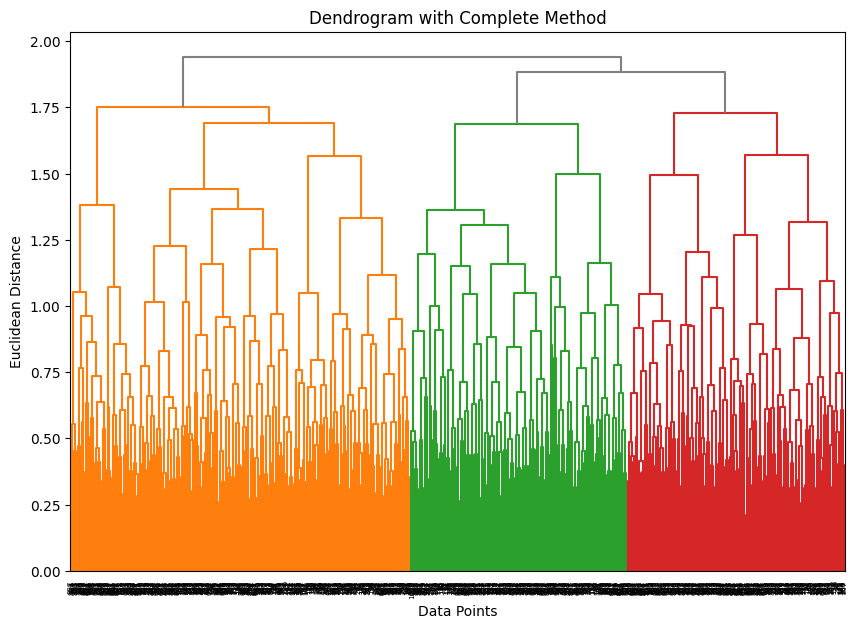

In [ ]:
# Max Distance
n_clusters = 3
linked = linkage(df, method='complete', metric='euclidean')
cluster_labels = fcluster(linked, t=n_clusters, criterion='distance')

color_threshold = linked[-(n_clusters-1), 2]

# Plot dendrogram dengan color_threshold
plt.figure(figsize=(10, 7))
sch.dendrogram(linked,
           color_threshold=color_threshold,
           above_threshold_color='grey',
           labels=np.arange(1, df.shape[0] + 1))
plt.title("Dendrogram with Complete Method")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

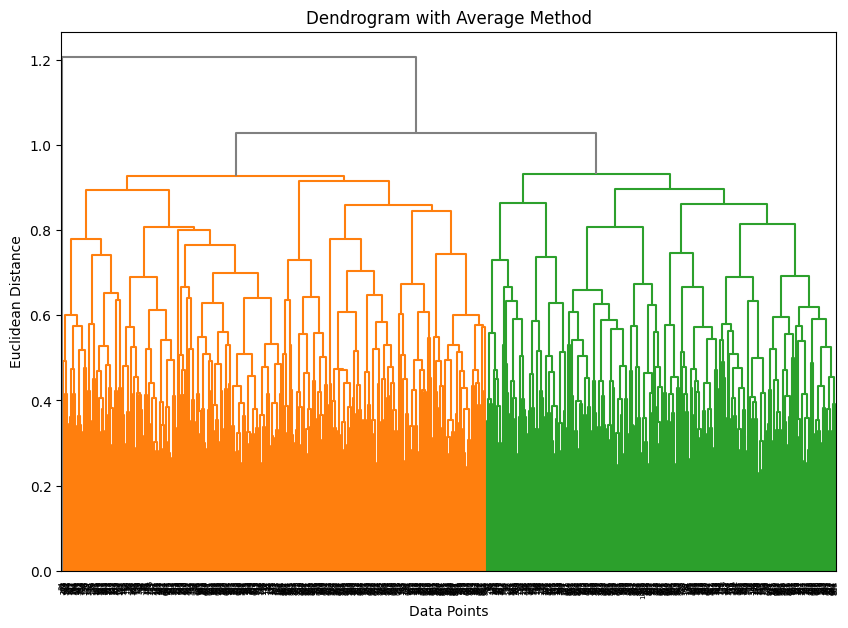

In [ ]:
# Average Distance
n_clusters = 3
linked = linkage(df, method='average', metric='euclidean')
cluster_labels = fcluster(linked, t=n_clusters, criterion='distance')

color_threshold = linked[-(n_clusters-1), 2]

# Plot dendrogram dengan color_threshold
plt.figure(figsize=(10, 7))
sch.dendrogram(linked,
           color_threshold=color_threshold,
           above_threshold_color='grey',
           labels=np.arange(1, df.shape[0] + 1))
plt.title("Dendrogram with Average Method")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

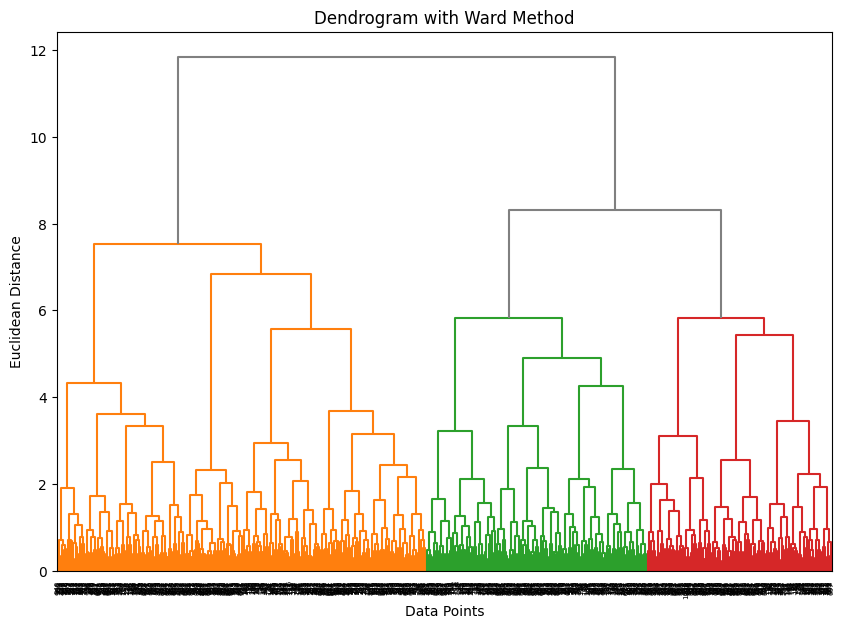

In [ ]:
# Ward Method
n_clusters = 3
linked = linkage(df, method='ward', metric='euclidean')
cluster_labels = fcluster(linked, t=n_clusters, criterion='distance')

color_threshold = linked[-(n_clusters-1), 2]

# Plot dendrogram dengan color_threshold
plt.figure(figsize=(10, 7))
sch.dendrogram(linked,
           color_threshold=color_threshold,
           above_threshold_color='grey',
           labels=np.arange(1, df.shape[0] + 1))
plt.title("Dendrogram with Ward Method")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

In [ ]:

# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(df)
kmeans_silhouette = silhouette_score(df, kmeans_labels)
print(f"Silhouette Score K-Means Clustering: {kmeans_silhouette}")

# Hierarchical Clustering
linkage_methods = ['ward', 'single', 'complete', 'average']
silhouette_scores = {} # Menyimpan silhouette score untuk setiap metode

for method in linkage_methods:
    hc = AgglomerativeClustering(n_clusters=3, linkage=method)
    hc_labels = hc.fit_predict(df)
    hc_silhouette = silhouette_score(df, hc_labels)
    silhouette_scores[method] = hc_silhouette # Menyimpan skor
    print(f"Silhouette Score Hierarchical Clustering ({method}): {hc_silhouette}")


Silhouette Score K-Means Clustering: 0.14658124287379237
Silhouette Score Hierarchical Clustering (ward): 0.10899491544651255
Silhouette Score Hierarchical Clustering (single): 0.06476467866723777
Silhouette Score Hierarchical Clustering (complete): 0.09847504472557157
Silhouette Score Hierarchical Clustering (average): 0.11608111943492254
